## 4.1 Obstacle Avoidance

**(a)**

In [ ]:
def signed_distances(s, centers, radii):
    """Compute signed distances to circular obstacles."""
    centers = jnp.reshape(centers, (-1, 2))
    radii = jnp.reshape(radii, (-1,))

    d = jnp.linalg.norm(s[:2] - centers, axis=1) - radii

    return d

**(b)**

In [ ]:
@partial(jax.jit, static_argnums=(0,))
@partial(jax.vmap, in_axes=(None, 0, 0))
def affinize(f, s, u):
    """Affinize the function `f(s, u)` around `(s, u)`."""
    A, B = jax.jacobian(f, argnums=(0, 1))(s, u)
    c = f(s, u) - A @ s - B @ u
    return A, B, c

**(c)**

Linearizing $f$ and $d$ around the current iterate $(s_{\cdot|t}^{(i)}, u_{\cdot|t}^{(i)})$:

$$
A_{f,k|t}^{(i)} = \frac{\partial f}{\partial s}\bigg|_{s_{k|t}^{(i)}, u_{k|t}^{(i)}}, \quad
B_{f,k|t}^{(i)} = \frac{\partial f}{\partial u}\bigg|_{s_{k|t}^{(i)}, u_{k|t}^{(i)}}, \quad
c_{f,k|t}^{(i)} = f(s_{k|t}^{(i)}, u_{k|t}^{(i)}) - A_{f,k|t}^{(i)} s_{k|t}^{(i)} - B_{f,k|t}^{(i)} u_{k|t}^{(i)}
$$

$$
A_{d,k|t}^{(i)} = \frac{\partial d}{\partial s}\bigg|_{s_{k|t}^{(i)}}, \quad
c_{d,k|t}^{(i)} = d(s_{k|t}^{(i)}) - A_{d,k|t}^{(i)} s_{k|t}^{(i)}
$$

The convex sub-problem is:

$$
\begin{aligned}
\min_{s_{\cdot|t},\, u_{\cdot|t}} \quad
  & (s_{N|t} - s_\text{goal})^\top P\,(s_{N|t} - s_\text{goal})
  + \sum_{k=0}^{N-1}\left[(s_{k|t} - s_\text{goal})^\top Q\,(s_{k|t} - s_\text{goal}) + u_{k|t}^\top R\,u_{k|t}\right] \\
\text{s.t.} \quad
  & s_{0|t} = s(t) \\
  & s_{k+1|t} = A_{f,k|t}^{(i)} s_{k|t} + B_{f,k|t}^{(i)} u_{k|t} + c_{f,k|t}^{(i)}, \quad k = 0,\dots,N-1 \\
  & A_{d,k|t}^{(i)} s_{k|t} + c_{d,k|t}^{(i)} \geq 0, \quad k = 0,\dots,N
\end{aligned}
$$

**(d)**

Each $d_j(s) = \|(x,y) - (x_j, y_j)\|_2 - r_j$ is convex (norm minus a constant). For any convex function $g$, the first-order condition gives $g(x) \geq g(\bar{x}) + \nabla g(\bar{x})^\top (x - \bar{x})$ for all $x$. Rearranging, $g(x) \geq \underbrace{\nabla g(\bar{x})^\top}_{A_d} x + \underbrace{g(\bar{x}) - \nabla g(\bar{x})^\top \bar{x}}_{c_d}$, so

$$d(s_{k|t}) \geq A_{d,k|t}^{(i)} s_{k|t} + c_{d,k|t}^{(i)}$$

Therefore $A_{d,k|t}^{(i)} s_{k|t} + c_{d,k|t}^{(i)} \geq 0 \implies d(s_{k|t}) \geq 0$. The linearized constraint is a conservative inner approximation of the true obstacle constraint, so feasibility of the sub-problem guarantees safety.

**(e)**

In [ ]:
def scp_iteration(f, d, s0, s_goal, s_prev, u_prev, P, Q, R):
    """Solve a single SCP sub-problem for the obstacle avoidance problem."""
    n = s_prev.shape[-1]
    m = u_prev.shape[-1]
    N = u_prev.shape[0]

    Af, Bf, cf = affinize(f, s_prev[:-1], u_prev)
    Af, Bf, cf = np.array(Af), np.array(Bf), np.array(cf)
    Ad, _, cd = affinize(
        lambda s, _: d(s), s_prev, jnp.concatenate((u_prev, u_prev[-1:]))
    )
    Ad, cd = np.array(Ad), np.array(cd)

    s_cvx = cvx.Variable((N + 1, n))
    u_cvx = cvx.Variable((N, m))

    objective = 0.0
    constraints = [s_cvx[0] == s0]

    for k in range(N):
        objective += cvx.quad_form(s_cvx[k] - s_goal, Q) + cvx.quad_form(u_cvx[k], R)
        constraints += [s_cvx[k + 1] == Af[k] @ s_cvx[k] + Bf[k] @ u_cvx[k] + cf[k]]
        constraints += [Ad[k] @ s_cvx[k] + cd[k] >= 0]

    objective += cvx.quad_form(s_cvx[N] - s_goal, P)
    constraints += [Ad[N] @ s_cvx[N] + cd[N] >= 0]

    prob = cvx.Problem(cvx.Minimize(objective), constraints)
    prob.solve()
    s = s_cvx.value
    u = u_cvx.value
    J = prob.objective.value
    return s, u, J

**(f)**

In [ ]:
# Solve the MPC problem at time `t`
s_mpc[t], u_mpc[t] = solve_obstacle_avoidance_scp(
    f, d, s, s_goal, N, P, Q, R, eps, N_scp, s_init=s_init, u_init=u_init
)

# Push the state `s` forward in time with a closed-loop MPC input
s = np.array(f(s, u_mpc[t, 0]))

**(g)**

| $N$ | $N_\text{SCP}$ | `total_time` (s) | `total_control_cost` |
|-----|-----------------|-------------------|----------------------|
| 5   | 5               | 13.91             | 6.93                 |
| 2   | 5               | 13.08             | 11.18                |
| 5   | 2               | 8.45              | 4.43                 |
| 15  | 2               | 11.49             | 4.50                 |

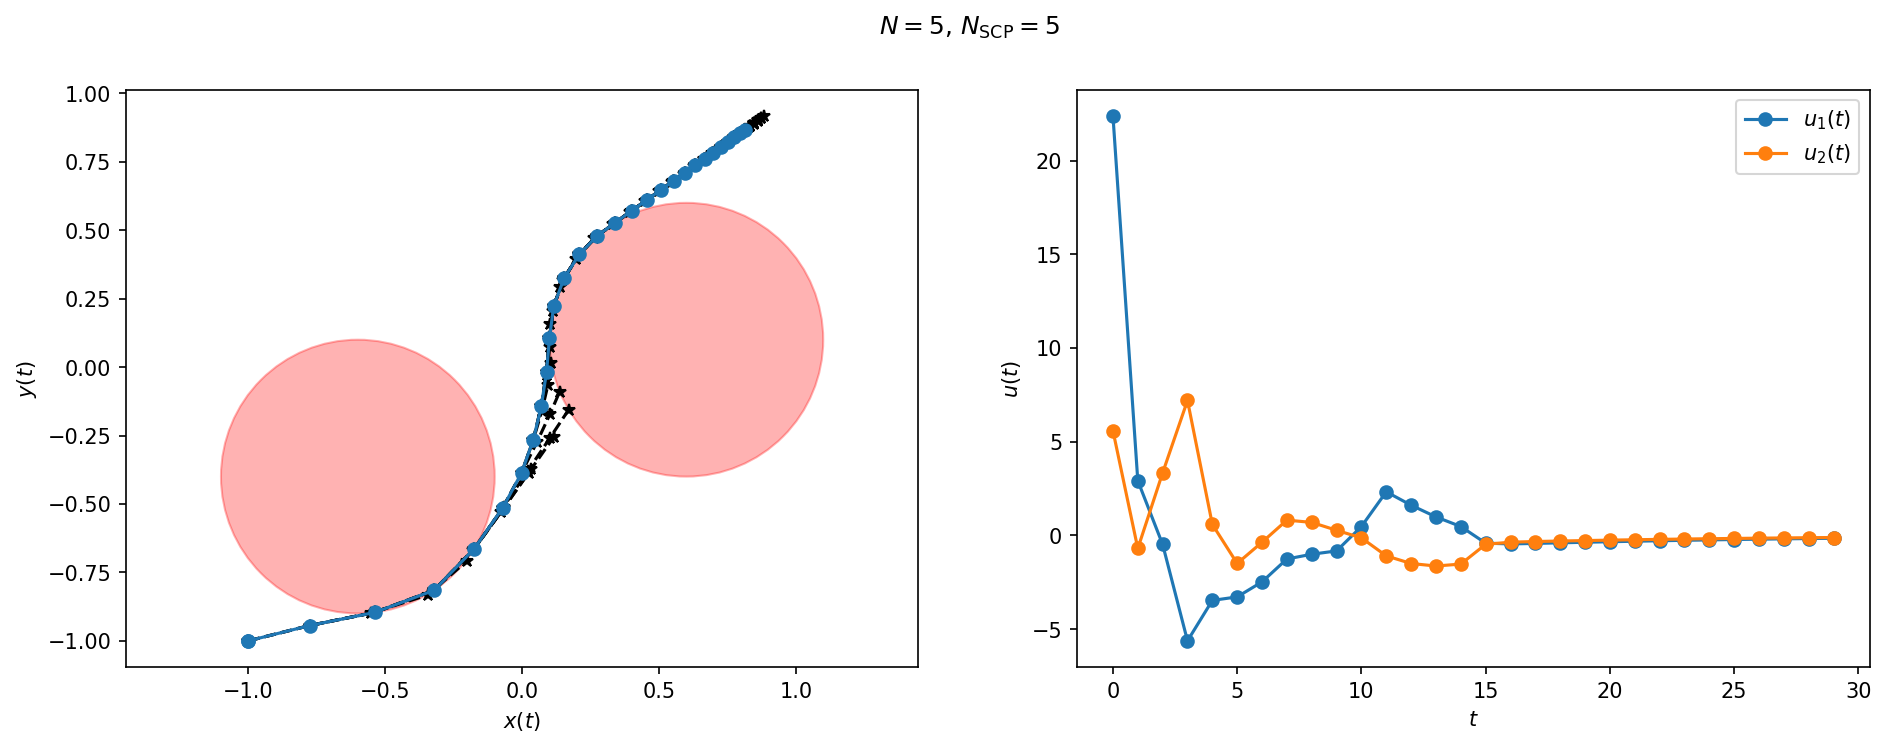

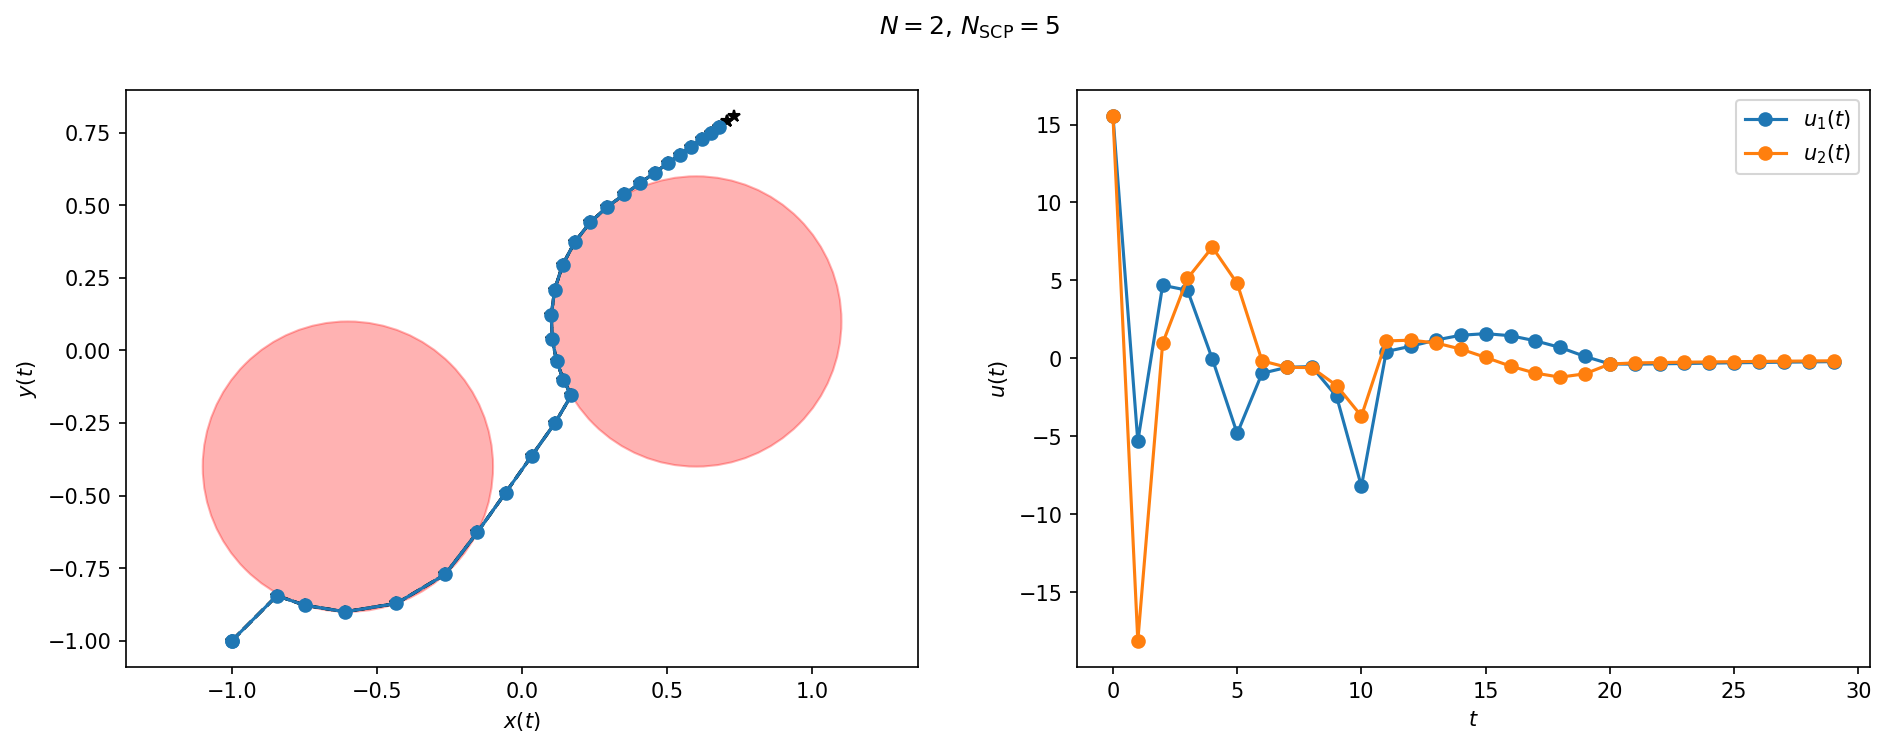

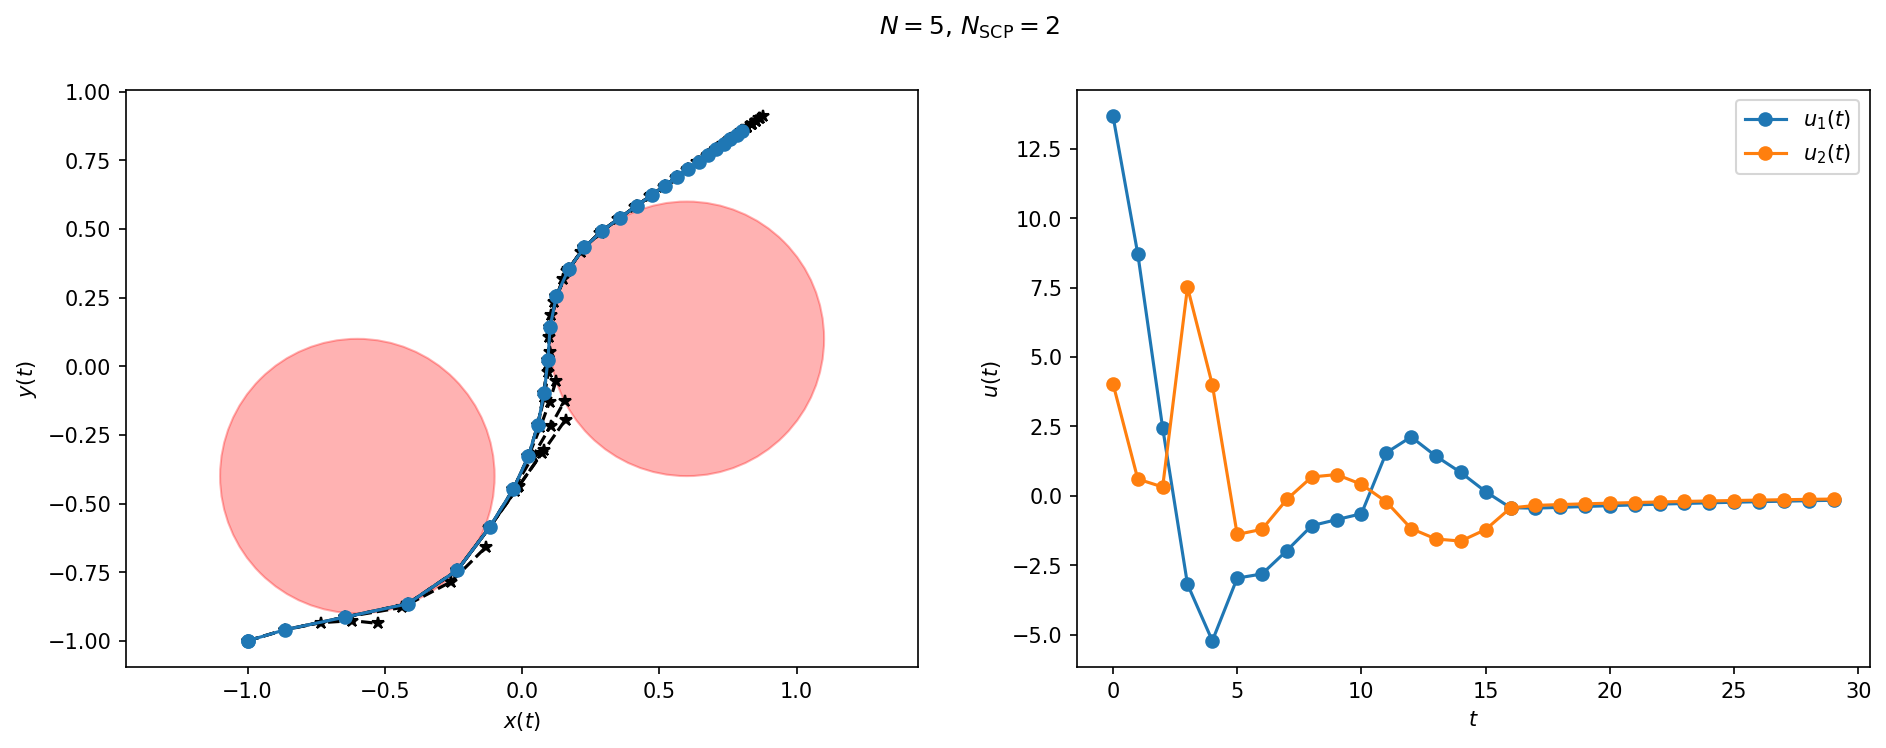

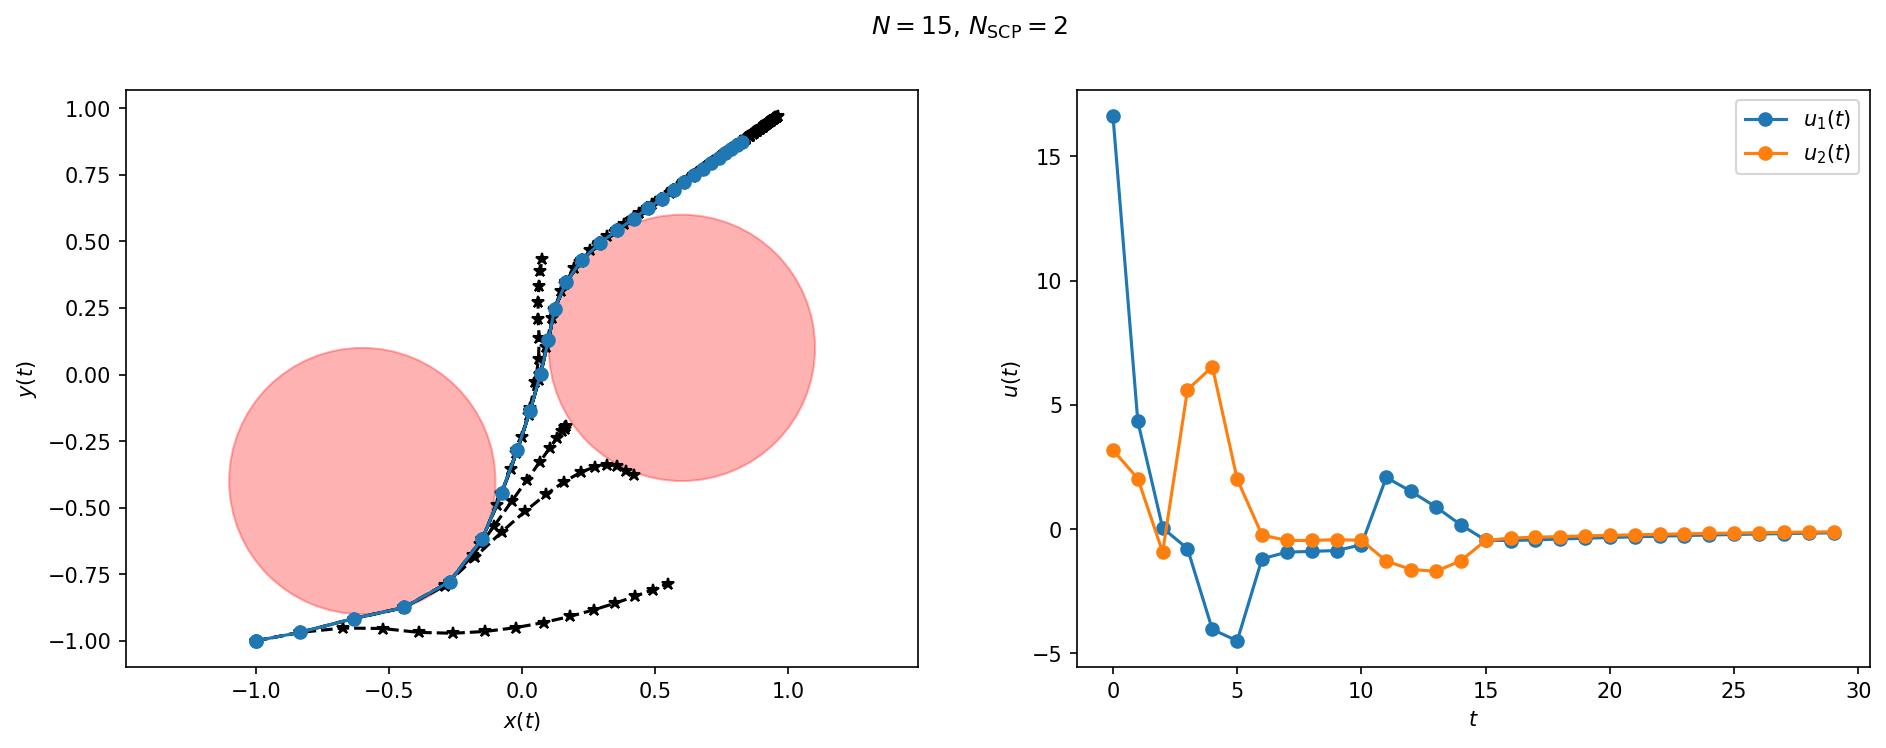

In [1]:
from IPython.display import display, Image

for fname in [
    "../soln_obstacle_avoidance_N=5_Nscp=5.png",
    "../soln_obstacle_avoidance_N=2_Nscp=5.png",
    "../soln_obstacle_avoidance_N=5_Nscp=2.png",
    "../soln_obstacle_avoidance_N=15_Nscp=2.png",
]:
    display(Image(filename=fname))

All four cases successfully steer the system from $(-1,-1)$ toward $(1,1)$ while avoiding both obstacles.

With $N=5$ and $N_\text{SCP}=5$, the trajectory smoothly navigates between the two obstacles, though the control inputs show a large initial spike in $u_1$ before settling, resulting in a cost of 6.93.

Reducing the horizon to $N=2$ (with $N_\text{SCP}=5$) makes the controller myopic, since it cannot anticipate the obstacles early enough. As a result, the trajectory hugs the obstacle boundaries more tightly and the controls become much more aggressive and oscillatory, which explains the highest control cost of 11.18.

With $N=5$ and $N_\text{SCP}=2$, the trajectory is very similar to the $N=5, N_\text{SCP}=5$ case but with smaller control magnitudes. This is the fastest run (8.45s) and achieves the lowest cost (4.43), suggesting that SCP already converges in just 2 iterations here.

Increasing the horizon to $N=15$ (with $N_\text{SCP}=2$) allows the planner to see further ahead, as shown by the longer planned trajectories. However, the actual trajectory and control cost (4.50) are comparable to the $N=5, N_\text{SCP}=2$ case, while the computation takes longer (11.49s) because of the larger optimization problem. Overall, a moderate horizon with few SCP iterations provides the best trade-off between computation time and trajectory quality.